# Dig-in: matchup for float 7902226 (cycle 5)

A **live** exploration notebook for a single profile JXP flagged as a known
PACE matchup — referred to as *"(7902226, 4)"* in his numbering, which pins to
**GDAC cycle 5** (timestamp 2025-02-18T20:27 UTC, 27.48 °N 46.22 °W; see the
Pre-Stage-4 convergence in `claude_prompts/coding_stage4.md`). Change `CYCLE`
below to explore a different profile.

It runs end-to-end against **real services** (argopy + earthaccess), so it needs
network access and an Earthdata Login. It is intentionally **not** part of the
offline Sphinx docs build.

Steps: fetch the float profile (argopy) → mixed-layer summary → discover the
PACE granule (earthaccess) → match with the engine → plot the profile, the
granule, and the closest-pixel `Rrs` spectrum.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

# --- target profile -------------------------------------------------------
WMO = 7902226
CYCLE = 5            # JXP's "(7902226, 4)" == GDAC cycle 5 (converged)

# --- argopy source --------------------------------------------------------
# Read the GDAC NetCDF directly: the Ifremer BGC ERDDAP returns intermittent
# 408/timeout errors. mode="expert" returns a recent real-time profile's
# measured params; "standard"/"research" prefer delayed-mode/adjusted fields
# that do not exist yet for a recent cycle and would yield 0 points.
ARGO_SRC = "gdac"
ARGO_MODE = "expert"

# --- matchup criteria (see pab.matchup.engine.MatchupConfig) --------------
DTIME_HOURS = 24.0   # |profile - granule| window; tighten toward ~3 h as data allow
N_SPECTRA = 10       # nearest unflagged pixels to keep
BBOX_PAD = 0.5       # deg half-width of the CMR search box around the float

## 1. Authenticate with Earthdata

`earthaccess.login()` looks for a `~/.netrc`, the `EARTHDATA_*` env vars, or prompts interactively. Opening L2 granules is fastest in-region (AWS `us-west-2`); out of region it falls back to an authenticated HTTPS read.

In [2]:
import earthaccess
auth = earthaccess.login()
print("authenticated:", auth.authenticated)

authenticated: True


## 2. Fetch the float profile (argopy)

Uses the PAB ingestion seam `pab.argo.fetch` against the **GDAC** source
(`ARGO_SRC`/`ARGO_MODE` above). We deliberately **do not** apply the blanket
`fetch.filter_quality` here: in `expert` mode the dataset carries *all* BGC
parameters (incl. `NITRATE`, `PH_IN_SITU_TOTAL`) whose QC flags are `0`/`3` for
this profile, and `filter_qc(QC=[1,2])` drops a level if *any* parameter fails —
which would empty the dataset. The core variables we use
(`PRES`/`BBP700`/`CHLA`/`PSAL`/`TEMP`) are all QC=1 here, and the mixed-layer
summary applies its own de-spike + IQR screen to `BBP700`.

In [3]:
import argopy
from pab.argo import fetch

with argopy.set_options(api_timeout=600):
    ds_argo = fetch.fetch_profile(WMO, CYCLE, src=ARGO_SRC, mode=ARGO_MODE)

meta, variables = next(fetch.iter_profiles(ds_argo))
pres = variables["PRES"]
bbp700 = variables.get("BBP700")
chla = variables.get("CHLA")
print("profile:", meta["wmo"], "/", meta["cycle"])
print("time   :", meta["time"])
print("lat/lon:", round(meta["latitude"], 4), round(meta["longitude"], 4))
print("levels :", pres.size)

profile: 7902226 / 5
time   : 2025-02-18T20:27:49.002184704
lat/lon: 27.4787 -46.2214
levels : 509


## 3. Mixed-layer summary

The Bisson/de Boyer Montégut MLD and de-spiked mixed-layer means (`pab.argo.summary`).

In [4]:
from pab.argo import summary

summ = summary.summarize_profile(
    pres,
    bbp700=bbp700,
    chla=chla,
    psal=variables.get("PSAL"),
    temp=variables.get("TEMP"),
    lon=meta["longitude"],
    lat=meta["latitude"],
)
print(f"MLD            : {summ['mld']:.1f} m ({summ['mld_method']})")
print(f"bbp700 (ML)    : {summ['bbp700']:.3e} +/- {summ['bbp700_std']:.1e} m^-1")
print(f"chla   (ML)    : {summ['chla']:.3f} mg m^-3")
print(f"n in MLD       : {summ['n_points']}")

MLD            : 30.0 m (deBoyerMontegut_0.03)
bbp700 (ML)    : 4.274e-04 +/- 2.5e-05 m^-1
chla   (ML)    : 0.091 mg m^-3
n in MLD       : 15


## 4. Discover the PACE granule (earthaccess)

A CMR search for `PACE_OCI_L2_AOP` granules in a small box around the float, within `DTIME_HOURS` of the profile time.

In [5]:
from datetime import datetime, timedelta
from pab.pace import discover

t = datetime.fromisoformat(meta["time"])
win = (t - timedelta(hours=DTIME_HOURS), t + timedelta(hours=DTIME_HOURS))
lon, lat = meta["longitude"], meta["latitude"]
bbox = (lon - BBOX_PAD, lat - BBOX_PAD, lon + BBOX_PAD, lat + BBOX_PAD)

results = discover.search_granules(
    temporal=(win[0].isoformat(), win[1].isoformat()),
    bounding_box=bbox,
)
print(f"{len(results)} candidate granule(s)")
gran = discover.granule_table(results)
gran[["id", "time", "CC", "url"]]

4 candidate granule(s)


,id,time,CC,url
0,PACE_OCI.20250218T152312.L2.OC_AOP.V3_1.nc,2025-02-18 15:25:42+00:00,51.2,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...
1,PACE_OCI.20250218T152312.L2.OC_AOP.V3_2.nc,2025-02-18 15:25:42+00:00,51.2,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...
2,PACE_OCI.20250219T155847.L2.OC_AOP.V3_1.nc,2025-02-19 16:01:17+00:00,34.6,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...
3,PACE_OCI.20250219T155847.L2.OC_AOP.V3_2.nc,2025-02-19 16:01:17+00:00,34.6,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...


## 5. Match the profile to a granule (the engine)

Build engine candidates from the discovery table and let `find_matchup` open each (via `pab.pace.cloud.open_granule`), select the ~10 nearest **unflagged** pixels, and pick the best by (distance, dtime).

In [6]:
from pab.matchup import engine

candidates = [
    {"granule_id": str(r["id"]), "time": str(r["time"]), "source": r["url"]}
    for _, r in gran.iterrows()
]
profile = {
    "wmo": WMO, "cycle": CYCLE,
    "latitude": lat, "longitude": lon, "time": meta["time"],
}
cfg = engine.MatchupConfig(dtime_max_hours=DTIME_HOURS, n_spectra=N_SPECTRA)
match = engine.find_matchup(profile, candidates, config=cfg)

assert match is not None, "no granule qualified — widen DTIME_HOURS / BBOX_PAD"
print("matchup_id :", match.matchup_id)
print("granule_id :", match.granule_id)
print(f"distance   : {match.distance_km:.2f} km (float -> nearest pixel)")
print(f"dtime      : {match.dtime_hours:.2f} h")
print("n_spectra  :", match.n_spectra)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

matchup_id : 7902226_5_PACE_OCI.20250219T155847.L2.OC_AOP.V3_2.nc
granule_id : PACE_OCI.20250219T155847.L2.OC_AOP.V3_2.nc
distance   : 0.45 km (float -> nearest pixel)
dtime      : 19.56 h
n_spectra  : 10


## 6. Plot the float profile

`BBP700` / `CHLA` vs pressure with the MLD line and the de-spiked overlay (`pab.argo.qa`).

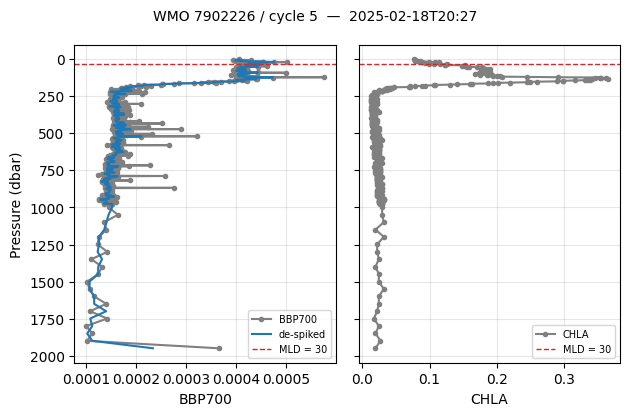

In [7]:
from pab.argo import qa

fig = qa.plot_profile(
    pres, bbp700=bbp700, chla=chla, mld=summ["mld"],
    title=f"WMO {WMO} / cycle {CYCLE}  —  {meta['time'][:16]}",
)
plt.show()

## 7. Plot the granule

The matched granule's `Rrs` near 442 nm, with the float position (red star) and the selected matchup pixels (white circles) overlaid. Re-open the chosen granule through the same cloud seam.

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

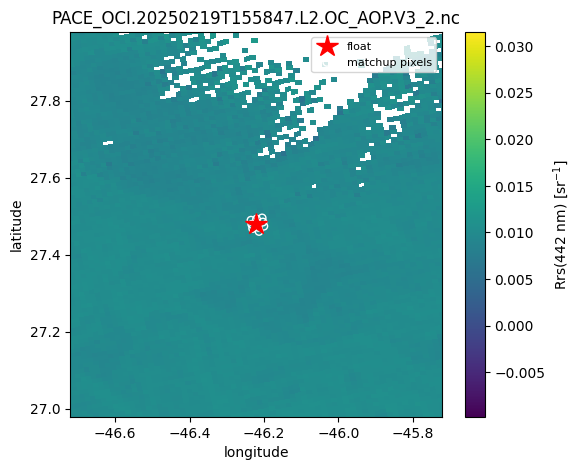

In [8]:
from pab.pace import cloud

url = gran.loc[gran["id"].astype(str) == match.granule_id, "url"].iloc[0]
gds = cloud.open_granule(url)

wl = np.asarray(gds["wavelength"].values)
b = int(np.argmin(np.abs(wl - 442.0)))   # band nearest 442 nm
rrs_band = np.asarray(gds["Rrs"].isel(wl=b).values)
glon = np.asarray(gds["longitude"].values)
glat = np.asarray(gds["latitude"].values)

fig, ax = plt.subplots(figsize=(6, 5))
pc = ax.pcolormesh(glon, glat, rrs_band, shading="nearest", cmap="viridis")
fig.colorbar(pc, ax=ax, label=f"Rrs({wl[b]:.0f} nm) [sr$^{{-1}}$]")
ax.plot(lon, lat, "r*", ms=16, label="float")
ax.scatter(
    [p["longitude"] for p in match.pixels],
    [p["latitude"] for p in match.pixels],
    s=30, facecolors="none", edgecolors="w", label="matchup pixels",
)
# zoom to the neighbourhood of the float
ax.set_xlim(lon - BBOX_PAD, lon + BBOX_PAD)
ax.set_ylim(lat - BBOX_PAD, lat + BBOX_PAD)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"{match.granule_id}")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## False-color RGB composite (real PACE)

A false-color composite of the **matched PACE granule** built from three `Rrs` channels (`pab.plotting.scene.scene_quicklook`, default R/G/B ≈ 645/555/470 nm, scaled by a shared brightness reference so the natural ocean colour is preserved). The full OCI granule is large, so we crop to a window around the float for a fast, zoomed scene; the matchup-pixel indices are remapped into the crop. The float is the red star, the analyzed pixels are white circles, and `l2_flags`-flagged pixels are greyed.

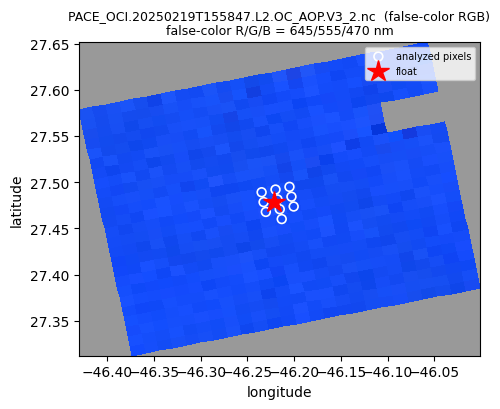

In [9]:
from pab.plotting import scene

# Crop the full granule to a window around the float for a fast, zoomed
# scene. Center on the analyzed pixels' centroid (they sit on the float)
# and remap their indices into the crop, dropping any that fall outside.
ixs = [p["ix"] for p in match.pixels]; iys = [p["iy"] for p in match.pixels]
cx, cy = int(round(np.mean(ixs))), int(round(np.mean(iys)))
half = 12
x0, y0 = max(cx - half, 0), max(cy - half, 0)
sub = gds.isel(x=slice(x0, cx + half + 1), y=slice(y0, cy + half + 1))
nxs, nys = sub.sizes["x"], sub.sizes["y"]
sub_pixels = [{"ix": p["ix"] - x0, "iy": p["iy"] - y0} for p in match.pixels
              if 0 <= p["ix"] - x0 < nxs and 0 <= p["iy"] - y0 < nys]

fig = scene.scene_quicklook(
    sub, lat, lon, pixels=sub_pixels,
    title=f"{match.granule_id}  (false-color RGB)",
)
plt.show()

## 8. `Rrs` spectrum from the closest pixel

The nearest unflagged pixel (`rank == 1`) with its `Rrs_unc` band — the spectrum the BING fit (Stage 5) will consume.

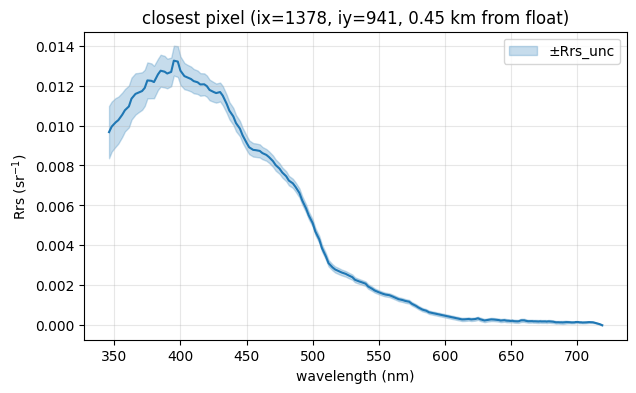

In [10]:
closest = match.pixels[0]   # rank 1 = nearest
wave = closest["wavelength"]
rrs = closest["Rrs"]
unc = closest["Rrs_unc"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wave, rrs, "-", color="C0", lw=1.5)
ax.fill_between(wave, rrs - unc, rrs + unc, color="C0", alpha=0.25, label="±Rrs_unc")
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel("Rrs (sr$^{-1}$)")
ax.set_title(
    f"closest pixel (ix={closest['ix']}, iy={closest['iy']}, "
    f"{closest['distance_km']:.2f} km from float)"
)
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## Compare with PCA-NN

JR row 6: PACE_OCI.20250219T155847.L2.OC_AOP.V3_1.nc (0.46 km from float)


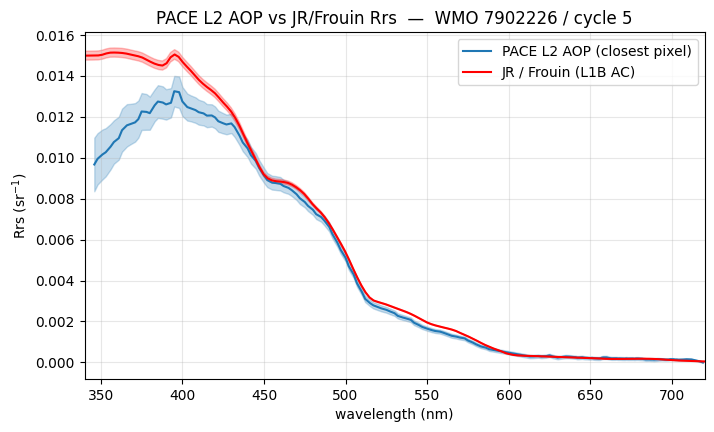

In [11]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# Robert Frouin ("JR") provided Rrs spectra derived from PACE *L1B* with his
# atmospheric correction. We *import* the biomass-paper helper (we do not copy
# it); point BING_ANALYSIS_PY at it if it lives elsewhere.
BING_ANALYSIS_PY = os.environ.get(
    "BING_ANALYSIS_PY",
    os.path.expanduser("~/Oceanography/python/bing/papers/biomass/Analysis/py"),
)
if BING_ANALYSIS_PY not in sys.path:
    sys.path.insert(0, BING_ANALYSIS_PY)
import jr_utils as jr

# Pick the JR row nearest the float (the table's trailing rows are comments,
# dropped by requiring finite PACE_lat/lon).
jr_df = jr.load_jr_data()
valid = jr_df.dropna(subset=["PACE_lat", "PACE_lon"])
cos = np.cos(np.radians(lat))
d_km = np.sqrt((valid["PACE_lat"] - lat) ** 2
               + ((valid["PACE_lon"] - lon) * cos) ** 2) * 111.0
jr_idx = int(d_km.idxmin())
jr_rrs = jr.extract_rrs(jr_idx)
wl_jr, m_jr, s_jr = jr_rrs["wavelengths"], jr_rrs["Rrs_mean"], jr_rrs["Rrs_std"]
print(f"JR row {jr_idx}: {jr_df.loc[jr_idx, 'AOP_file']} "
      f"({d_km.loc[jr_idx]:.2f} km from float)")

# PACE L2 AOP closest pixel (from section 8)
wl_p, rrs_p, unc_p = closest["wavelength"], closest["Rrs"], closest["Rrs_unc"]

fig, ax = plt.subplots(figsize=(8, 4.5))
# PACE L2 AOP (blue) with its Rrs_unc band
ax.plot(wl_p, rrs_p, "-", color="C0", lw=1.5, label="PACE L2 AOP (closest pixel)")
ax.fill_between(wl_p, rrs_p - unc_p, rrs_p + unc_p, color="C0", alpha=0.25)
# JR / Frouin (red) with its Rrs_std band
ax.plot(wl_jr, m_jr, "-", color="red", lw=1.5, label="JR / Frouin (L1B AC)")
ax.fill_between(wl_jr, m_jr - s_jr, m_jr + s_jr, color="red", alpha=0.25)

ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("Rrs (sr$^{-1}$)")
ax.set_xlim(340, 720)
ax.set_title(f"PACE L2 AOP vs JR/Frouin Rrs  —  WMO {WMO} / cycle {CYCLE}")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Log10 version

JR row 6: PACE_OCI.20250219T155847.L2.OC_AOP.V3_1.nc (0.46 km from float)


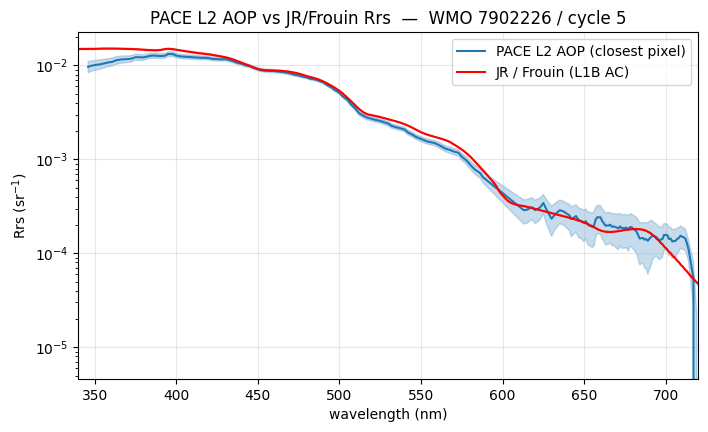

In [12]:
# Robert Frouin ("JR") provided Rrs spectra derived from PACE *L1B* with his
# atmospheric correction. We *import* the biomass-paper helper (we do not copy
# it); point BING_ANALYSIS_PY at it if it lives elsewhere.
BING_ANALYSIS_PY = os.environ.get(
    "BING_ANALYSIS_PY",
    os.path.expanduser("~/Oceanography/python/bing/papers/biomass/Analysis/py"),
)
if BING_ANALYSIS_PY not in sys.path:
    sys.path.insert(0, BING_ANALYSIS_PY)
import jr_utils as jr

# Pick the JR row nearest the float (the table's trailing rows are comments,
# dropped by requiring finite PACE_lat/lon).
jr_df = jr.load_jr_data()
valid = jr_df.dropna(subset=["PACE_lat", "PACE_lon"])
cos = np.cos(np.radians(lat))
d_km = np.sqrt((valid["PACE_lat"] - lat) ** 2
               + ((valid["PACE_lon"] - lon) * cos) ** 2) * 111.0
jr_idx = int(d_km.idxmin())
jr_rrs = jr.extract_rrs(jr_idx)
wl_jr, m_jr, s_jr = jr_rrs["wavelengths"], jr_rrs["Rrs_mean"], jr_rrs["Rrs_std"]
print(f"JR row {jr_idx}: {jr_df.loc[jr_idx, 'AOP_file']} "
      f"({d_km.loc[jr_idx]:.2f} km from float)")

# PACE L2 AOP closest pixel (from section 8)
wl_p, rrs_p, unc_p = closest["wavelength"], closest["Rrs"], closest["Rrs_unc"]

fig, ax = plt.subplots(figsize=(8, 4.5))
# PACE L2 AOP (blue) with its Rrs_unc band
ax.plot(wl_p, rrs_p, "-", color="C0", lw=1.5, label="PACE L2 AOP (closest pixel)")
ax.fill_between(wl_p, rrs_p - unc_p, rrs_p + unc_p, color="C0", alpha=0.25)
# JR / Frouin (red) with its Rrs_std band
ax.plot(wl_jr, m_jr, "-", color="red", lw=1.5, label="JR / Frouin (L1B AC)")
ax.fill_between(wl_jr, m_jr - s_jr, m_jr + s_jr, color="red", alpha=0.25)

ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("Rrs (sr$^{-1}$)")
ax.set_yscale('log')
ax.set_xlim(340, 720)
ax.set_title(f"PACE L2 AOP vs JR/Frouin Rrs  —  WMO {WMO} / cycle {CYCLE}")
ax.legend()
ax.grid(alpha=0.3)
plt.show()